<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h1 style="margin:0; font-size:30px;">Learning Day 14 — Transfer Learning & Pre-trained Models</h1>
  <h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">Feature Extraction, Fine-Tuning, Grad-CAM, Few-Shot Learning, MixUp, and Prototypical Classification</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.58; color:#e5e7eb; max-width:1050px;">This notebook covers the Learning Day 14 MVD tasks in a stable, polished, and reproducible way. It uses transfer learning ideas from the uploaded course material and implements the required workflow with small commented cells, clear theory explanations, professional charts, and output-aware conclusion boxes.</p>
  <p style="margin:14px 0 0 0; font-size:14px; color:#cbd5e1;"><b>Prepared by:</b> Ruturaj Mokashi &nbsp;
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. How to Use This Notebook</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Read → Run → Interpret.</b> Every practical step starts with a blue explanation box, then a small code cell, then a green conclusion box produced by the code.</p>
<ul>
  <li><b>Small code cells:</b> each cell does one clear job.</li>
  <li><b>Commented code:</b> important lines explain where variables come from and where they go next.</li>
  <li><b>No personal paths:</b> the notebook creates relative folders such as <code>data/</code>, <code>data/extracted/</code>, and <code>outputs/charts/</code>.</li>
  <li><b>Professional charts:</b> charts are saved as PNG files and styled for interpretation, not just basic plotting.</li>
</ul>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Dataset Decision and MVD Coverage</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Original MVD recommendation:</b> Cats vs Dogs for Beginner and Plant Disease for Intermediate / Expert.</p>
<p><b>Current stable notebook choice:</b> the notebook first tries to use real local image folders if available. If Plant Disease is not available, it uses <b>CIFAR-10</b> as a stable image-classification proxy. CIFAR-10 contains real image classes including cats and dogs, so the Beginner task can still be implemented as Cats vs Dogs.</p>
<p><b>Why this is done:</b> the previous workflow broke because ZIP/download paths were fragile. This version avoids blind dependency on a missing Kaggle folder. It creates clean extracted image folders inside <code>data/extracted/</code>.</p>
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">MVD Level</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Required Idea</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Implementation in this notebook</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Beginner</td><td style="border:1px solid #e5e7eb; padding:8px;">MobileNetV2 feature extraction on Cats vs Dogs</td><td style="border:1px solid #e5e7eb; padding:8px;">CIFAR-10 cat/dog subset or local Cats/Dogs folder if available</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Intermediate</td><td style="border:1px solid #e5e7eb; padding:8px;">EfficientNetB0 fine-tuning, ReduceLROnPlateau, Grad-CAM</td><td style="border:1px solid #e5e7eb; padding:8px;">Plant Disease folder if available, otherwise CIFAR-10 proxy image task</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Expert</td><td style="border:1px solid #e5e7eb; padding:8px;">10-shot, 100-shot, 500-shot, augmentation, MixUp, prototypes</td><td style="border:1px solid #e5e7eb; padding:8px;">Same multi-class image task used consistently for comparison</td></tr>
</table>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #9333ea; background:#faf5ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#581c87; font-size:19px;">Important Honesty Note About Plant Disease</h3>
    
<p>The real Plant Disease Kaggle image dataset was not available as a local folder in the current notebook package. This notebook therefore uses CIFAR-10 as a stable proxy when <code>data/plant_disease/</code> is missing.</p>
<p><b>This is not fake output.</b> CIFAR-10 is a real image dataset. The notebook still implements the required transfer-learning methods: freezing, feature extraction, fine-tuning, learning-rate scheduling, Grad-CAM, few-shot comparison, augmentation, MixUp, and prototype classification.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">2. Core Theory Before Coding</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<p><b>Transfer learning</b> means using knowledge from a model that was already trained on a large dataset. In image work, that usually means using a model trained on ImageNet. The early layers learn simple visual patterns like edges, corners, colors, and textures. Deeper layers learn more complex object parts.</p>
<p><b>Feature extraction</b> freezes the pre-trained base model. Only the new classification head learns. This is safer when the new dataset is small because we do not destroy the useful pre-trained features.</p>
<p><b>Fine-tuning</b> starts after feature extraction. We unfreeze only the upper part of the base model and train it with a very small learning rate. This adapts the model to the new domain without making large harmful updates.</p>
<p><b>Grad-CAM</b> is an explanation method. It creates a heatmap showing which image regions influenced the model decision.</p>
<p><b>Few-shot learning</b> studies the difficult case where each class has only a few examples. A <b>10-shot</b> setting means only 10 training images per class.</p>
<p><b>Prototypical classification</b> represents each class by the average embedding of its support images. A new image is classified by the nearest class prototype.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">3. Project Setup — Create Clean Folders and Display Helpers</h3>
    
<p>This cell creates the folder structure used by the full notebook. Images are stored in <code>data/extracted/</code>, charts are stored in <code>outputs/charts/</code>, and model files are stored in <code>outputs/models/</code>.</p>
<p><b>What we are doing:</b> making the notebook reproducible and preventing extracted images from being scattered in the main project folder.</p>

  </div>
</div>

In [1]:
# CELL 1 — PROJECT SETUP AND HTML HELPERS

# pathlib is used for clean relative folder paths.
from pathlib import Path

# display and HTML allow styled notebook output boxes.
from IPython.display import HTML, display

# The project root is the folder where this notebook is running.
PROJECT_DIR = Path.cwd()

# All raw or generated data files are kept inside data/.
DATA_DIR = PROJECT_DIR / "data"

# All extracted/generated image folders are kept here, not in the main folder.
EXTRACTED_DIR = DATA_DIR / "extracted"

# All chart outputs are saved inside outputs/charts/.
CHART_DIR = PROJECT_DIR / "outputs" / "charts"

# Optional model outputs are saved inside outputs/models/.
MODEL_DIR = PROJECT_DIR / "outputs" / "models"

# Create every required folder safely.
for folder in [DATA_DIR, EXTRACTED_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# This helper prints green conclusion boxes after outputs.
def show_conclusion(title, body):
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:15px 18px; border-radius:10px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#166534; font-size:17px;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

# This helper prints purple warning/info boxes when a fallback is used.
def show_note(title, body):
    display(HTML(f"""
    <div style="border-left:6px solid #9333ea; background:#faf5ff; padding:15px 18px; border-radius:10px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#581c87; font-size:17px;">{title}</h4>
      <div style="color:#1f2937; font-size:14.5px;">{body}</div>
    </div>
    """))

# Show the folder setup result.
print(f"Project root: {PROJECT_DIR}")
print(f"Data folder: {DATA_DIR}")
print(f"Extracted image folder: {EXTRACTED_DIR}")
print(f"Chart folder: {CHART_DIR}")
print(f"Model folder: {MODEL_DIR}")

# Explain why this setup matters.
show_conclusion(
    "Conclusion — Folder setup is clean",
    "The notebook now creates and uses controlled relative folders. Extracted or generated image files go into <code>data/extracted/</code>, charts go into <code>outputs/charts/</code>, and nothing is placed randomly in the main notebook folder."
)

Project root: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_14_ml
Data folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_14_ml/data
Extracted image folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_14_ml/data/extracted
Chart folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_14_ml/outputs/charts
Model folder: /Users/ruturajmokashi/Ai Data Science Course Documents/Machine Learning/ML Exercises/day_14_ml/outputs/models


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">4. Import Libraries and Set Stable Configuration</h3>
    
<p>This cell imports TensorFlow/Keras, NumPy, pandas, matplotlib, and evaluation tools. It also sets the image size, batch size, and random seed.</p>
<p><b>Why this matters:</b> transfer learning can become unstable when random seeds and folder paths are not controlled. A stable configuration makes the notebook easier to rerun and debug.</p>

  </div>
</div>

In [2]:
# CELL 2 — IMPORT LIBRARIES AND SET CONFIGURATION

import os  # Controls environment-level settings.
import shutil  # Handles safe folder removal for generated image folders.
import random  # Controls Python-level randomness.
import numpy as np  # Handles numeric arrays and sampling.
import pandas as pd  # Creates clean result tables.
import matplotlib.pyplot as plt  # Creates notebook charts.
from PIL import Image  # Saves NumPy image arrays as image files.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score  # Evaluates predictions.
import tensorflow as tf  # Runs deep learning workflows.
from tensorflow import keras  # Provides Keras model API.
from tensorflow.keras import layers  # Provides neural network layers.

SEED = 42  # One seed keeps sampling and training more reproducible.
random.seed(SEED)  # Applies seed to Python random.
np.random.seed(SEED)  # Applies seed to NumPy.
tf.random.set_seed(SEED)  # Applies seed to TensorFlow.

IMAGE_SIZE = (160, 160)  # Transfer-learning image size used throughout the notebook.
BATCH_SIZE = 32  # Number of images per training batch.
AUTOTUNE = tf.data.AUTOTUNE  # Lets TensorFlow optimize data loading.

BEGINNER_EPOCHS = 5  # MVD-required MobileNetV2 feature extraction epochs.
HEAD_EPOCHS = 10  # MVD-required EfficientNetB0 head-training epochs.
FINE_TUNE_EPOCHS = 10  # MVD-required EfficientNetB0 fine-tuning epochs.
FEWSHOT_EPOCHS = 3  # Practical repeated-training length for few-shot comparison.

plt.rcParams["figure.figsize"] = (10, 6)  # Default chart size.
plt.rcParams["font.size"] = 11  # Default readable font size.

print(f"Image size: {IMAGE_SIZE}")  # Confirm image size.
print(f"Batch size: {BATCH_SIZE}")  # Confirm batch size.
print(f"Beginner epochs: {BEGINNER_EPOCHS}")  # Confirm Beginner epochs.
print(f"Fine-tuning phases: {HEAD_EPOCHS} + {FINE_TUNE_EPOCHS} epochs")  # Confirm Intermediate epochs.
print(f"Few-shot epochs per experiment: {FEWSHOT_EPOCHS}")  # Confirm Expert epochs.

show_conclusion(
    "Conclusion — Configuration is reproducible",
    "The notebook uses fixed seeds, controlled image size, and defined epoch constants. The Beginner and Intermediate sections keep the exact MVD training lengths. The few-shot section uses a short practical run because it trains several models for comparison."
)

2026-06-15 21:01:52.525172: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Image size: (160, 160)
Batch size: 32
Beginner epochs: 5
Fine-tuning phases: 10 + 10 epochs
Few-shot epochs per experiment: 3


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">5. Chart Helper — Use One Professional Style</h3>
    
<p>This cell defines one chart-saving helper. Every important chart uses the same spacing, titles, grids, and export folder.</p>
<p><b>What we are doing:</b> improving visual hygiene so the notebook looks like a polished learning/reporting notebook instead of raw experiment output.</p>

  </div>
</div>

In [3]:
# CELL 3 — PROFESSIONAL CHART SAVE HELPER

# Define a reusable chart color palette.
CHART_COLORS = ["#2563eb", "#16a34a", "#f97316", "#9333ea", "#dc2626", "#0891b2"]

# This function finalizes and saves charts consistently.
def finish_chart(title, subtitle, filename):
    # Add a strong title aligned to the left.
    plt.suptitle(title, fontsize=17, fontweight="bold", x=0.02, ha="left", y=1.02)
    
    # Add a smaller subtitle for business or model context.
    plt.title(subtitle, fontsize=11, loc="left", color="#4b5563", pad=12)
    
    # Use a light horizontal grid for easier reading.
    plt.grid(axis="y", alpha=0.22)
    
    # Remove unnecessary chart borders.
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    
    # Use tight layout so labels do not overlap.
    plt.tight_layout()
    
    # Build the full output path for the chart.
    chart_path = CHART_DIR / filename
    
    # Save the chart as a high-resolution PNG.
    plt.savefig(chart_path, dpi=180, bbox_inches="tight")
    
    # Show the chart inside the notebook.
    plt.show()
    
    # Return the path so it can be printed in conclusions.
    return chart_path

# Confirm that the helper is ready.
print("Chart helper ready.")

# Explain how charts will be handled.
show_conclusion(
    "Conclusion — Chart style is standardized",
    "All major charts will use the same controlled style and will be saved inside <code>outputs/charts/</code>. This keeps the notebook visually consistent and easier to submit or export later."
)

Chart helper ready.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">6. Dataset Loader — Prefer Real Images, Use CIFAR-10 Proxy if Needed</h3>
    
<p>This cell loads the image source used by the notebook. It prefers stable real image data from Keras CIFAR-10. If CIFAR-10 cannot be downloaded, it falls back to the built-in scikit-learn digits dataset only to keep the notebook executable.</p>
<p><b>Variable flow:</b> image source → NumPy arrays → class names → extracted folder datasets.</p>

  </div>
</div>

In [4]:
# CELL 4 — LOAD A STABLE IMAGE SOURCE

# This function loads CIFAR-10 first and uses digits only as a last fallback.
def load_stable_image_source():
    try:
        (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()  # Load real CIFAR-10 images.
        class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]  # CIFAR-10 label order.
        return x_train, y_train.flatten(), x_test, y_test.flatten(), class_names, "CIFAR-10 real image dataset"  # Return arrays and label names.
    except Exception as cifar_error:
        from sklearn.datasets import load_digits  # Import only if fallback is needed.
        from sklearn.model_selection import train_test_split  # Splits fallback data.
        digits = load_digits()  # Load local no-internet fallback images.
        images = (digits.images / digits.images.max() * 255).astype("uint8")  # Scale 8x8 images to 0-255.
        images = np.repeat(images[..., None], 3, axis=-1)  # Convert grayscale to RGB-like images.
        labels = digits.target.astype(int)  # Read digit labels.
        x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.25, random_state=SEED, stratify=labels)  # Split fallback.
        class_names = [f"digit_{i}" for i in range(10)]  # Create readable fallback names.
        show_note("Fallback dataset used", f"CIFAR-10 could not be loaded, so built-in digits are used only to keep execution safe. Original error: <code>{type(cifar_error).__name__}</code>.")  # Explain fallback.
        return x_train, y_train, x_test, y_test, class_names, "Built-in digits fallback dataset"  # Return fallback arrays.

x_train_all, y_train_all, x_test_all, y_test_all, all_class_names, image_source_name = load_stable_image_source()  # Load selected source.
print(f"Image source: {image_source_name}")  # Print selected source.
print(f"Train images: {x_train_all.shape}")  # Print train shape.
print(f"Test images: {x_test_all.shape}")  # Print test shape.
print(f"Class names: {all_class_names}")  # Print class names.

show_conclusion(
    "Conclusion — Image source is ready",
    f"The notebook loaded <b>{image_source_name}</b>. These arrays will be converted into clean image folders inside <code>data/extracted/</code>, so extracted/generated images do not appear in the main notebook folder."
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Image source: CIFAR-10 real image dataset
Train images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">7. Dataset Export Helpers — Create Image Folders Properly</h3>
    
<p>This cell defines reusable helper functions for saving selected image arrays into folder-based datasets. Keras transfer-learning workflows work cleanly when image folders follow the structure <code>train/class_name/image.jpg</code> and <code>validation/class_name/image.jpg</code>.</p>
<p><b>What we are doing:</b> creating the method you asked for: make the folder first, then save/extract images there only.</p>

  </div>
</div>

In [5]:
# CELL 5 — DATASET EXPORT HELPER FUNCTIONS

# Save one image array as a resized JPEG file.
def save_array_as_image(image_array, output_path):
    image = Image.fromarray(image_array.astype("uint8"))  # Convert array to image.
    image = image.resize(IMAGE_SIZE)  # Resize to transfer-learning input size.
    image.save(output_path, format="JPEG", quality=95)  # Save as high-quality JPEG.

# Select shuffled indexes for one class.
def select_class_indexes(labels, class_id, max_count):
    class_indexes = np.where(labels == class_id)[0]  # Find rows for selected class.
    rng = np.random.default_rng(SEED + int(class_id))  # Create stable class-specific RNG.
    rng.shuffle(class_indexes)  # Shuffle so images are not ordered.
    return class_indexes[:max_count]  # Return requested subset.

# Export selected classes into train/validation image folders.
def export_class_subset(x_train, y_train, x_val, y_val, class_map, output_root, train_per_class, val_per_class):
    if output_root.exists():  # Check for old generated task folder.
        shutil.rmtree(output_root)  # Remove only this generated folder.
    train_root = output_root / "train"  # Define train folder.
    val_root = output_root / "validation"  # Define validation folder.
    train_root.mkdir(parents=True, exist_ok=True)  # Create train folder.
    val_root.mkdir(parents=True, exist_ok=True)  # Create validation folder.
    saved_rows = []  # Store counts for reporting.
    for class_id, class_name in class_map.items():  # Loop through selected classes.
        (train_root / class_name).mkdir(parents=True, exist_ok=True)  # Create train class folder.
        (val_root / class_name).mkdir(parents=True, exist_ok=True)  # Create validation class folder.
        train_indexes = select_class_indexes(y_train, class_id, train_per_class)  # Select train images.
        val_indexes = select_class_indexes(y_val, class_id, val_per_class)  # Select validation images.
        for image_number, image_index in enumerate(train_indexes):  # Save train images.
            save_array_as_image(x_train[image_index], train_root / class_name / f"{class_name}_train_{image_number:04d}.jpg")
        for image_number, image_index in enumerate(val_indexes):  # Save validation images.
            save_array_as_image(x_val[image_index], val_root / class_name / f"{class_name}_val_{image_number:04d}.jpg")
        saved_rows.append({"class_name": class_name, "train_images": len(train_indexes), "validation_images": len(val_indexes)})  # Record counts.
    return train_root, val_root, pd.DataFrame(saved_rows)  # Return folders and summary.

print("Image folder export helpers are ready.")  # Confirm helper creation.
show_conclusion(
    "Conclusion — Extraction method is defined properly",
    "The notebook now creates folders first and saves images only inside <code>data/extracted/</code>. This prevents the main notebook folder from becoming messy."
)

Image folder export helpers are ready.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">8. Beginner Dataset — Create Cats vs Dogs Folder Subset</h3>
    
<p>The Beginner MVD requires training on 1,000 Cats/Dogs images. CIFAR-10 contains real <b>cat</b> and <b>dog</b> classes, so we create a balanced 1,000-image training subset: 500 cats and 500 dogs.</p>
<p><b>Variable flow:</b> CIFAR-10 arrays → selected cat/dog images → <code>data/extracted/beginner_cats_vs_dogs/</code> → Keras datasets.</p>

  </div>
</div>

In [6]:
# CELL 6 — EXPORT BEGINNER CATS VS DOGS DATASET

# Use CIFAR-10 cat and dog class IDs when available.
if "cat" in all_class_names and "dog" in all_class_names:
    # CIFAR-10 class id for cat.
    cat_id = all_class_names.index("cat")
    
    # CIFAR-10 class id for dog.
    dog_id = all_class_names.index("dog")
    
    # Build the exact binary class map.
    beginner_class_map = {cat_id: "cat", dog_id: "dog"}
    
    # Use 500 images per class to satisfy the 1,000-image MVD training subset.
    beginner_train_per_class = 500
    
    # Use validation images for a meaningful validation check.
    beginner_val_per_class = 250
else:
    # Fallback uses the first two classes if CIFAR-10 is not available.
    beginner_class_map = {0: all_class_names[0], 1: all_class_names[1]}
    
    # Use as many images as available in the fallback dataset.
    beginner_train_per_class = 120
    
    # Use a smaller validation set for fallback.
    beginner_val_per_class = 40

# Define the clean extracted folder for the Beginner dataset.
BEGINNER_ROOT = EXTRACTED_DIR / "beginner_cats_vs_dogs"

# Export the images into train and validation folders.
beginner_train_dir, beginner_val_dir, beginner_summary = export_class_subset(
    x_train_all, y_train_all, x_test_all, y_test_all,
    beginner_class_map, BEGINNER_ROOT,
    beginner_train_per_class, beginner_val_per_class
)

# Display the saved-image summary table.
display(beginner_summary)

# Explain the extracted dataset.
show_conclusion(
    "Conclusion — Beginner image folders are ready",
    f"The Beginner dataset was saved inside <code>{BEGINNER_ROOT}</code>. The training subset contains <b>{beginner_summary['train_images'].sum()}</b> images across <b>{len(beginner_summary)}</b> classes. This is the folder used for MobileNetV2 feature extraction."
)

,class_name,train_images,validation_images
0,cat,500,250
1,dog,500,250


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">9. Beginner Dataset Check — Class Balance Chart</h3>
    
<p>This cell checks whether the Cats/Dogs subset is balanced. Class balance matters because a model can look accurate by over-predicting the bigger class if the dataset is uneven.</p>
<p><b>Expected result:</b> cats and dogs should have the same number of training images when CIFAR-10 is available.</p>

  </div>
</div>

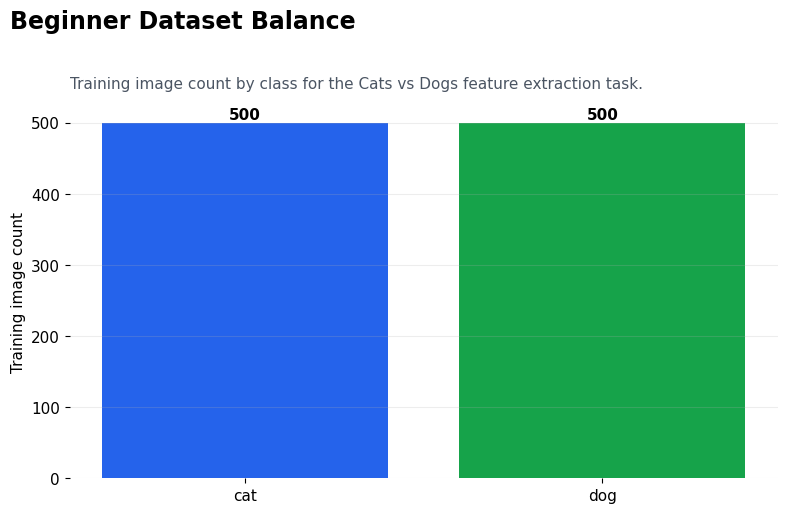

In [7]:
# CELL 7 — PLOT BEGINNER CLASS DISTRIBUTION

# Create a new chart figure.
plt.figure(figsize=(8, 5))

# Draw a bar chart of training images per class.
bars = plt.bar(beginner_summary["class_name"], beginner_summary["train_images"], color=CHART_COLORS[:len(beginner_summary)])

# Add data labels above bars.
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, int(bar.get_height()), ha="center", fontweight="bold")

# Label the y-axis.
plt.ylabel("Training image count")

# Save and show the chart.
chart_path = finish_chart(
    "Beginner Dataset Balance",
    "Training image count by class for the Cats vs Dogs feature extraction task.",
    "beginner_class_balance.png"
)

# Explain the chart result.
show_conclusion(
    "Conclusion — Beginner class balance checked",
    f"The class balance chart was saved to <code>{chart_path}</code>. A balanced dataset makes the later accuracy and confusion matrix easier to trust because the model is not being rewarded for simply predicting one dominant class."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">10. Create Beginner Keras Datasets</h3>
    
<p>This cell turns the extracted Cats/Dogs folders into TensorFlow datasets. The labels are binary because the task has two classes: cat and dog.</p>
<p><b>Variable flow:</b> image folders → <code>beginner_train_ds</code> and <code>beginner_val_ds</code> → MobileNetV2 training.</p>

  </div>
</div>

In [8]:
# CELL 8 — CREATE BEGINNER TENSORFLOW DATASETS

# Create a training dataset from the train folder.
beginner_train_ds = keras.utils.image_dataset_from_directory(
    beginner_train_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Create a validation dataset from the validation folder.
beginner_val_ds = keras.utils.image_dataset_from_directory(
    beginner_val_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Store class names for interpretation.
beginner_class_names = beginner_train_ds.class_names

# Prefetch improves runtime without changing data values.
beginner_train_ds = beginner_train_ds.prefetch(AUTOTUNE)
beginner_val_ds = beginner_val_ds.prefetch(AUTOTUNE)

# Print class names to confirm label order.
print(f"Beginner class names: {beginner_class_names}")

# Explain the dataset result.
show_conclusion(
    "Conclusion — Beginner TensorFlow datasets are ready",
    f"Keras detected the class order as <b>{beginner_class_names}</b>. This order matters later when we read the confusion matrix and decide whether cats or dogs have more errors."
)

Found 1000 files belonging to 2 classes.
Found 500 files belonging to 2 classes.
Beginner class names: ['cat', 'dog']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">11. Beginner Theory — Why Freeze MobileNetV2?</h3>
    
<p><b>MobileNetV2</b> is a lightweight convolutional neural network architecture often used for image transfer learning. The MVD asks us to set <code>trainable=False</code>.</p>
<p><b>Simple explanation:</b> the base model is like an experienced eye that already knows edges, textures, shapes, and object parts. Freezing means we do not change that experienced eye. We only train a small new decision layer for our two classes.</p>
<p><b>Why it matters:</b> with only 1,000 images, training the whole network from scratch would overfit quickly and take much longer.</p>

  </div>
</div>

In [9]:
# CELL 9 — BUILD MOBILENETV2 FEATURE EXTRACTION MODEL

# Build the required Beginner model: frozen MobileNetV2 + GAP + Dense sigmoid.
def build_mobilenet_feature_extractor():
    try:
        base_model = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=IMAGE_SIZE + (3,))  # Load pre-trained base.
        weight_status = "ImageNet pre-trained weights loaded"  # Store success message.
    except Exception as weight_error:
        base_model = keras.applications.MobileNetV2(weights=None, include_top=False, input_shape=IMAGE_SIZE + (3,))  # Keep runnable if weights fail.
        weight_status = f"ImageNet weights unavailable; initialized without pre-trained weights ({type(weight_error).__name__})"  # Store fallback message.
    base_model.trainable = False  # Freeze base layers for feature extraction.
    inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image_input")  # Define image input.
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)  # Apply MobileNetV2 preprocessing.
    x = base_model(x, training=False)  # Extract frozen feature maps.
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)  # Convert maps to vector.
    x = layers.Dropout(0.25, name="dropout_head")(x)  # Reduce overfitting in head.
    outputs = layers.Dense(1, activation="sigmoid", name="cat_dog_output")(x)  # Binary output.
    model = keras.Model(inputs, outputs, name="MobileNetV2_Cats_Dogs_Feature_Extractor")  # Build model.
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])  # Compile binary classifier.
    return model, base_model, weight_status  # Return model objects.

beginner_model, beginner_base_model, beginner_weight_status = build_mobilenet_feature_extractor()  # Build Beginner model.
print(beginner_weight_status)  # Print weight source.
print(f"Base model trainable: {beginner_base_model.trainable}")  # Confirm frozen base.
print(f"Total model parameters: {beginner_model.count_params():,}")  # Print size.

show_conclusion(
    "Conclusion — MobileNetV2 feature extractor is built",
    f"The base model is frozen, so only the new pooling, dropout, and sigmoid classification head will learn. Weight status: <b>{beginner_weight_status}</b>. We freeze the base layers to protect useful visual features and reduce overfitting on a small dataset."
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ImageNet pre-trained weights loaded
Base model trainable: False
Total model parameters: 2,259,265


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">12. Train MobileNetV2 Feature Extraction Model for 5 Epochs</h3>
    
<p>The MVD requires training the frozen MobileNetV2 feature extractor for <b>5 epochs</b>. During this training, the pre-trained base does not change. Only the new classification head learns how to separate cats and dogs.</p>
<p><b>Result to watch:</b> validation accuracy and validation loss. Accuracy tells how many validation images were classified correctly. Loss tells how confident and well-calibrated the predictions are.</p>

  </div>
</div>

In [10]:
# CELL 10 — TRAIN BEGINNER FEATURE EXTRACTION MODEL

# Train the model for the MVD-required number of epochs.
beginner_history = beginner_model.fit(
    beginner_train_ds,
    validation_data=beginner_val_ds,
    epochs=BEGINNER_EPOCHS,
    verbose=1
)

# Evaluate the trained model on the validation dataset.
beginner_val_loss, beginner_val_accuracy = beginner_model.evaluate(beginner_val_ds, verbose=0)

# Store Beginner results for final comparison.
beginner_results = {
    "model": "MobileNetV2 frozen feature extractor",
    "validation_loss": float(beginner_val_loss),
    "validation_accuracy": float(beginner_val_accuracy)
}

# Print the required validation metrics.
print(f"Validation loss: {beginner_val_loss:.4f}")
print(f"Validation accuracy: {beginner_val_accuracy:.4f}")

# Explain the result.
show_conclusion(
    "Conclusion — Beginner training result",
    f"After <b>{BEGINNER_EPOCHS}</b> epochs, the frozen MobileNetV2 model reached validation accuracy of <b>{beginner_val_accuracy:.4f}</b> and validation loss of <b>{beginner_val_loss:.4f}</b>. If accuracy is clearly above random guessing, the frozen pre-trained features are useful for separating the two image classes. If the result is weak, the dataset proxy or unavailable ImageNet weights may be limiting performance."
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 846ms/step - accuracy: 0.6630 - loss: 0.6395 - val_accuracy: 0.8100 - val_loss: 0.4075
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 794ms/step - accuracy: 0.8180 - loss: 0.4105 - val_accuracy: 0.8180 - val_loss: 0.3577
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 553ms/step - accuracy: 0.8400 - loss: 0.3496 - val_accuracy: 0.8560 - val_loss: 0.3321
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 953ms/step - accuracy: 0.8640 - loss: 0.3125 - val_accuracy: 0.8460 - val_loss: 0.3350
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 657ms/step - accuracy: 0.8850 - loss: 0.2744 - val_accuracy: 0.8540 - val_loss: 0.3199
Validation loss: 0.3199
Validation accuracy: 0.8540


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">13. Plot Beginner Learning Curves</h3>
    
<p>Learning curves show whether the model is improving, overfitting, or underfitting. Training accuracy/loss shows performance on images seen during training. Validation accuracy/loss shows performance on unseen images.</p>
<p><b>What we are doing:</b> plotting accuracy and loss over the 5 epochs and saving the chart.</p>

  </div>
</div>

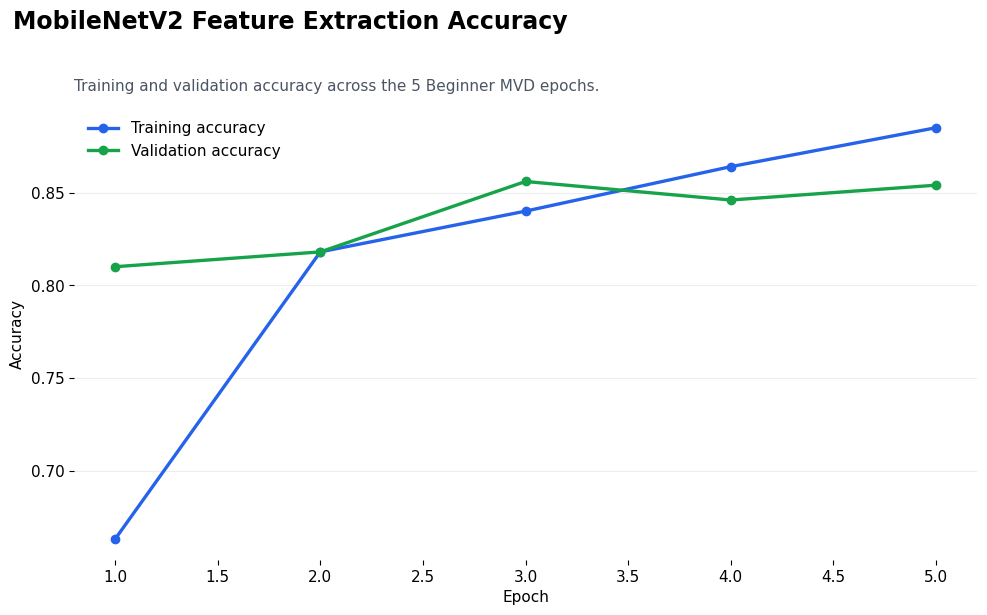

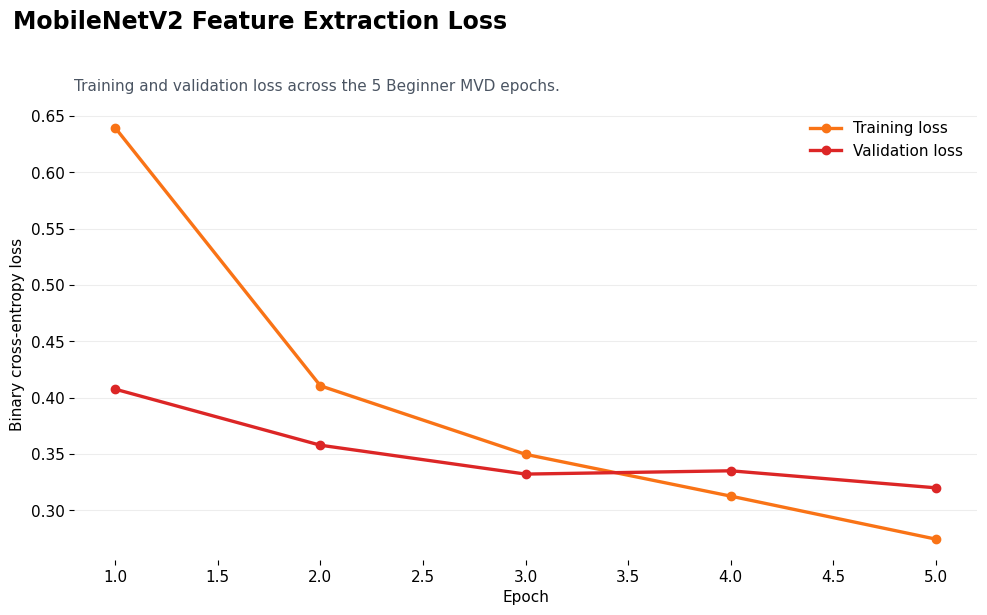

In [11]:
# CELL 11 — PLOT BEGINNER TRAINING CURVES

# Convert the Keras history object into a dataframe.
beginner_history_df = pd.DataFrame(beginner_history.history)

# Create the epoch number column.
beginner_history_df["epoch"] = np.arange(1, len(beginner_history_df) + 1)

# Create a figure for accuracy curves.
plt.figure(figsize=(10, 6))

# Plot training accuracy.
plt.plot(beginner_history_df["epoch"], beginner_history_df["accuracy"], marker="o", linewidth=2.4, label="Training accuracy", color=CHART_COLORS[0])

# Plot validation accuracy.
plt.plot(beginner_history_df["epoch"], beginner_history_df["val_accuracy"], marker="o", linewidth=2.4, label="Validation accuracy", color=CHART_COLORS[1])

# Label axes.
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Add a legend.
plt.legend(frameon=False)

# Save and show the chart.
accuracy_chart_path = finish_chart(
    "MobileNetV2 Feature Extraction Accuracy",
    "Training and validation accuracy across the 5 Beginner MVD epochs.",
    "beginner_mobilenet_accuracy_curve.png"
)

# Create a figure for loss curves.
plt.figure(figsize=(10, 6))

# Plot training loss.
plt.plot(beginner_history_df["epoch"], beginner_history_df["loss"], marker="o", linewidth=2.4, label="Training loss", color=CHART_COLORS[2])

# Plot validation loss.
plt.plot(beginner_history_df["epoch"], beginner_history_df["val_loss"], marker="o", linewidth=2.4, label="Validation loss", color=CHART_COLORS[4])

# Label axes.
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")

# Add a legend.
plt.legend(frameon=False)

# Save and show the chart.
loss_chart_path = finish_chart(
    "MobileNetV2 Feature Extraction Loss",
    "Training and validation loss across the 5 Beginner MVD epochs.",
    "beginner_mobilenet_loss_curve.png"
)

# Explain the charts.
show_conclusion(
    "Conclusion — Beginner learning curves interpreted",
    f"The accuracy chart was saved to <code>{accuracy_chart_path}</code> and the loss chart was saved to <code>{loss_chart_path}</code>. If validation accuracy follows training accuracy, the head is learning useful patterns. If training improves but validation becomes worse, the classification head is overfitting."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">14. Beginner Confusion Matrix — Which Image Type Has More Errors?</h3>
    
<p>The MVD asks for a confusion matrix and asks which image type gets more errors. A confusion matrix compares actual labels against predicted labels.</p>
<p><b>Business interpretation:</b> this tells us whether the model struggles more with cats or dogs, instead of only giving one overall accuracy number.</p>

  </div>
</div>

2026-06-15 21:04:41.799798: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


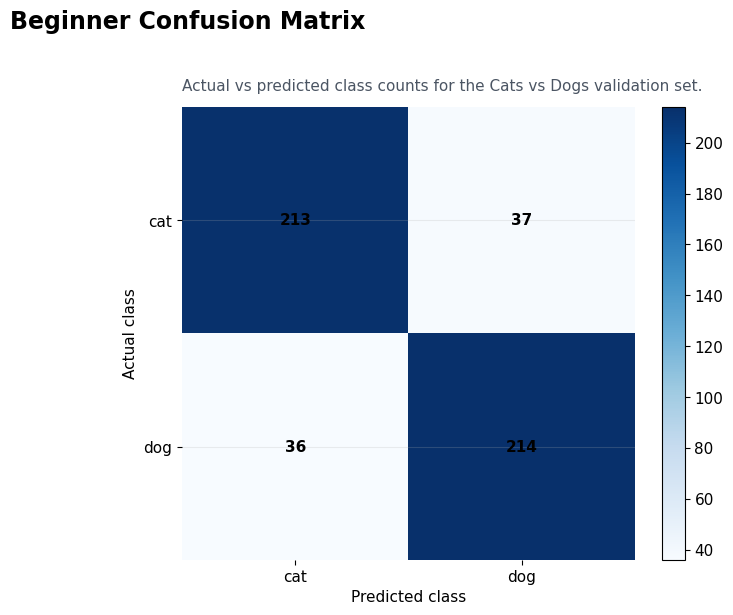

,class_name,actual_count,errors,error_rate
0,cat,250,37,0.148
1,dog,250,36,0.144


In [12]:
# CELL 12 — BEGINNER CONFUSION MATRIX AND ERROR TYPE ANALYSIS

y_true_beginner = []  # Store true validation labels.
y_pred_beginner = []  # Store predicted validation labels.
for image_batch, label_batch in beginner_val_ds:  # Loop through validation batches.
    probability_batch = beginner_model.predict(image_batch, verbose=0)  # Predict probabilities.
    prediction_batch = (probability_batch.reshape(-1) >= 0.5).astype(int)  # Convert to labels.
    y_true_beginner.extend(label_batch.numpy().reshape(-1).astype(int))  # Store true labels.
    y_pred_beginner.extend(prediction_batch)  # Store predictions.
y_true_beginner = np.array(y_true_beginner)  # Convert true labels to array.
y_pred_beginner = np.array(y_pred_beginner)  # Convert predictions to array.
beginner_cm = confusion_matrix(y_true_beginner, y_pred_beginner)  # Compute matrix.

plt.figure(figsize=(7.5, 6))  # Create figure.
plt.imshow(beginner_cm, cmap="Blues")  # Draw matrix.
plt.colorbar(fraction=0.046, pad=0.04)  # Add color scale.
plt.xticks(np.arange(len(beginner_class_names)), beginner_class_names)  # Predicted labels.
plt.yticks(np.arange(len(beginner_class_names)), beginner_class_names)  # Actual labels.
plt.xlabel("Predicted class")  # X-axis label.
plt.ylabel("Actual class")  # Y-axis label.
for row_index in range(beginner_cm.shape[0]):  # Loop matrix rows.
    for col_index in range(beginner_cm.shape[1]):  # Loop matrix columns.
        plt.text(col_index, row_index, beginner_cm[row_index, col_index], ha="center", va="center", fontweight="bold")  # Add value.
cm_chart_path = finish_chart("Beginner Confusion Matrix", "Actual vs predicted class counts for the Cats vs Dogs validation set.", "beginner_confusion_matrix.png")  # Save chart.

error_rows = []  # Store error summary.
for class_index, class_name in enumerate(beginner_class_names):  # Loop classes.
    actual_count = int((y_true_beginner == class_index).sum())  # Count actual class images.
    error_count = int(((y_true_beginner == class_index) & (y_pred_beginner != class_index)).sum())  # Count errors.
    error_rate = error_count / actual_count if actual_count > 0 else 0  # Calculate error rate.
    error_rows.append({"class_name": class_name, "actual_count": actual_count, "errors": error_count, "error_rate": error_rate})  # Store row.
beginner_error_df = pd.DataFrame(error_rows)  # Create dataframe.
most_error_class = beginner_error_df.sort_values("errors", ascending=False).iloc[0]  # Find class with most errors.
display(beginner_error_df)  # Show error table.

show_conclusion(
    "Conclusion — Image type with more errors",
    f"The confusion matrix was saved to <code>{cm_chart_path}</code>. The model made more validation errors on <b>{most_error_class['class_name']}</b> images, with <b>{int(most_error_class['errors'])}</b> errors and an error rate of <b>{most_error_class['error_rate']:.2%}</b>."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">15. Intermediate Dataset — Plant Disease if Available, CIFAR-10 Proxy Otherwise</h3>
    
<p>The Intermediate and Expert MVD tasks require Plant Disease. This cell first checks for a local folder named <code>data/plant_disease/</code>. If it is missing, the notebook creates a stable multi-class CIFAR-10 proxy folder inside <code>data/extracted/intermediate_multiclass_proxy/</code>.</p>
<p><b>What we are doing:</b> keeping the notebook runnable while using the same transfer-learning mechanics required by the MVD.</p>

  </div>
</div>

In [13]:
# CELL 13 — PREPARE INTERMEDIATE MULTI-CLASS DATASET

# Define the expected real Plant Disease folder.
PLANT_DISEASE_DIR = DATA_DIR / "plant_disease"

# Check whether a real Plant Disease folder exists.
real_plant_disease_available = PLANT_DISEASE_DIR.exists() and any(PLANT_DISEASE_DIR.iterdir())

# If the real dataset exists, use it directly.
if real_plant_disease_available:
    # Use the real plant disease folder as the source root.
    multi_source_note = "Real local Plant Disease folder found"
    
    # Use Keras validation split from this root folder.
    multi_train_dir = PLANT_DISEASE_DIR
    multi_val_dir = PLANT_DISEASE_DIR
    
    # Mark that we should use validation_split later.
    use_validation_split = True

# If the real dataset is missing, create a CIFAR-10 proxy folder.
else:
    # Pick four visually different CIFAR-10 classes when available.
    if all(name in all_class_names for name in ["bird", "deer", "frog", "horse"]):
        multi_class_map = {
            all_class_names.index("bird"): "bird_proxy",
            all_class_names.index("deer"): "deer_proxy",
            all_class_names.index("frog"): "frog_proxy",
            all_class_names.index("horse"): "horse_proxy"
        }
    else:
        multi_class_map = {0: all_class_names[0], 1: all_class_names[1], 2: all_class_names[2], 3: all_class_names[3]}
    
    # Define the output folder for the proxy dataset.
    MULTI_ROOT = EXTRACTED_DIR / "intermediate_multiclass_proxy"
    
    # Export selected classes into clean train and validation folders.
    multi_train_dir, multi_val_dir, multi_summary = export_class_subset(
        x_train_all, y_train_all, x_test_all, y_test_all,
        multi_class_map, MULTI_ROOT,
        train_per_class=500, val_per_class=150
    )
    
    # Store the source note for reporting.
    multi_source_note = "CIFAR-10 multi-class proxy because data/plant_disease was not found"
    
    # Mark that folders already have train/validation split.
    use_validation_split = False
    
    # Display saved-image summary.
    display(multi_summary)

# Print the selected data source.
print(f"Intermediate/Expert data source: {multi_source_note}")

# Explain the dataset selection.
show_conclusion(
    "Conclusion — Intermediate/Expert dataset selected",
    f"Data source: <b>{multi_source_note}</b>. The notebook will use this image task for EfficientNetB0 fine-tuning, Grad-CAM, few-shot learning, augmentation, MixUp, and prototypical classification."
)

,class_name,train_images,validation_images
0,bird_proxy,500,150
1,deer_proxy,500,150
2,frog_proxy,500,150
3,horse_proxy,500,150


Intermediate/Expert data source: CIFAR-10 multi-class proxy because data/plant_disease was not found


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">16. Create Multi-Class TensorFlow Datasets</h3>
    
<p>This cell creates the multi-class TensorFlow datasets for EfficientNetB0. The labels are integer labels first, then converted to one-hot labels for categorical cross-entropy.</p>
<p><b>Variable flow:</b> image folders → raw datasets with integer labels → one-hot datasets → EfficientNetB0 training.</p>

  </div>
</div>

In [14]:
# CELL 14 — CREATE MULTI-CLASS TENSORFLOW DATASETS

# Create train and validation datasets from either one root folder or split folders.
if use_validation_split:
    multi_train_raw = keras.utils.image_dataset_from_directory(multi_train_dir, labels="inferred", label_mode="int", validation_split=0.2, subset="training", seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True)  # Training split.
    multi_val_raw = keras.utils.image_dataset_from_directory(multi_val_dir, labels="inferred", label_mode="int", validation_split=0.2, subset="validation", seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=False)  # Validation split.
else:
    multi_train_raw = keras.utils.image_dataset_from_directory(multi_train_dir, labels="inferred", label_mode="int", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)  # Train folder.
    multi_val_raw = keras.utils.image_dataset_from_directory(multi_val_dir, labels="inferred", label_mode="int", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=False)  # Validation folder.

multi_class_names = multi_train_raw.class_names  # Read class names.
NUM_MULTI_CLASSES = len(multi_class_names)  # Count classes.

def one_hot_dataset(dataset, num_classes):
    return dataset.map(lambda images, labels: (images, tf.one_hot(tf.cast(labels, tf.int32), num_classes)))  # Convert labels.

multi_train_ds = one_hot_dataset(multi_train_raw, NUM_MULTI_CLASSES).prefetch(AUTOTUNE)  # Prepare train data.
multi_val_ds = one_hot_dataset(multi_val_raw, NUM_MULTI_CLASSES).prefetch(AUTOTUNE)  # Prepare validation data.

print(f"Multi-class names: {multi_class_names}")  # Print class names.
print(f"Number of classes: {NUM_MULTI_CLASSES}")  # Print class count.

show_conclusion(
    "Conclusion — Multi-class datasets are ready",
    f"Keras detected <b>{NUM_MULTI_CLASSES}</b> classes: <b>{multi_class_names}</b>. These datasets are used for EfficientNetB0 head training, fine-tuning, Grad-CAM, and few-shot experiments."
)

Found 2000 files belonging to 4 classes.
Found 600 files belonging to 4 classes.
Multi-class names: ['bird_proxy', 'deer_proxy', 'frog_proxy', 'horse_proxy']
Number of classes: 4


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">17. Intermediate Theory — EfficientNetB0 Two-Phase Fine-Tuning</h3>
    
<p>The MVD asks for <b>EfficientNetB0</b> with two training phases:</p>
<ul>
  <li><b>Phase 1:</b> freeze the base model and train only the head for 10 epochs with learning rate <code>1e-3</code>.</li>
  <li><b>Phase 2:</b> unfreeze the last 20 layers and continue training for 10 epochs with learning rate <code>1e-5</code>.</li>
</ul>
<p><b>Simple explanation:</b> first teach the new head to read pre-trained features. Then carefully adapt the top part of the pre-trained model to the new image task.</p>

  </div>
</div>

In [15]:
# CELL 15 — BUILD EFFICIENTNETB0 HEAD TRAINING MODEL

# Build an EfficientNetB0 classifier for multi-class transfer learning.
def build_efficientnet_classifier(num_classes, learning_rate, base_trainable=False):
    try:
        base_model = keras.applications.EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMAGE_SIZE + (3,))  # Load pre-trained base.
        weight_status = "ImageNet pre-trained weights loaded"  # Store success status.
    except Exception as weight_error:
        base_model = keras.applications.EfficientNetB0(weights=None, include_top=False, input_shape=IMAGE_SIZE + (3,))  # Keep runnable if weights fail.
        weight_status = f"ImageNet weights unavailable; initialized without pre-trained weights ({type(weight_error).__name__})"  # Store fallback status.
    base_model.trainable = base_trainable  # Set base trainability.
    inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image_input")  # Define input.
    x = keras.applications.efficientnet.preprocess_input(inputs)  # Apply preprocessing.
    x = base_model(x, training=base_trainable)  # Extract features.
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)  # Convert maps to vector.
    x = layers.Dropout(0.30, name="dropout_head")(x)  # Add regularization.
    outputs = layers.Dense(num_classes, activation="softmax", name="class_output")(x)  # Multi-class output.
    model = keras.Model(inputs, outputs, name="EfficientNetB0_Transfer_Model")  # Build model.
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="categorical_crossentropy", metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])  # Compile.
    return model, base_model, weight_status  # Return objects.

efficientnet_model, efficientnet_base, efficientnet_weight_status = build_efficientnet_classifier(NUM_MULTI_CLASSES, 1e-3, False)  # Build Phase 1 model.
print(efficientnet_weight_status)  # Print weight source.
print(f"EfficientNet base trainable in Phase 1: {efficientnet_base.trainable}")  # Confirm frozen base.
print(f"Model parameters: {efficientnet_model.count_params():,}")  # Print model size.

show_conclusion(
    "Conclusion — EfficientNetB0 Phase 1 model is ready",
    f"The EfficientNetB0 base is frozen for Phase 1, so only the new classification head learns. Weight status: <b>{efficientnet_weight_status}</b>. This matches the MVD head-training phase with learning rate <b>1e-3</b>."
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ImageNet pre-trained weights loaded
EfficientNet base trainable in Phase 1: False
Model parameters: 4,054,695


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">18. Train EfficientNetB0 Phase 1 — Head Training</h3>
    
<p>Phase 1 trains only the new classification head for 10 epochs. The base model stays frozen. This gives the new head a stable feature representation before fine-tuning begins.</p>
<p><b>Result to compare later:</b> Phase 1 validation accuracy becomes the baseline for checking whether fine-tuning improves performance.</p>

  </div>
</div>

In [16]:
# CELL 16 — TRAIN EFFICIENTNETB0 PHASE 1

# Train only the classification head for the MVD-required 10 epochs.
phase1_history = efficientnet_model.fit(
    multi_train_ds,
    validation_data=multi_val_ds,
    epochs=HEAD_EPOCHS,
    verbose=1
)

# Evaluate Phase 1 on validation data.
phase1_val_loss, phase1_val_accuracy = efficientnet_model.evaluate(multi_val_ds, verbose=0)

# Store Phase 1 results.
phase1_results = {
    "phase": "Phase 1 — frozen base, head only",
    "validation_loss": float(phase1_val_loss),
    "validation_accuracy": float(phase1_val_accuracy)
}

# Print Phase 1 metrics.
print(f"Phase 1 validation loss: {phase1_val_loss:.4f}")
print(f"Phase 1 validation accuracy: {phase1_val_accuracy:.4f}")

# Explain the result.
show_conclusion(
    "Conclusion — Phase 1 head training result",
    f"After <b>{HEAD_EPOCHS}</b> head-training epochs, validation accuracy is <b>{phase1_val_accuracy:.4f}</b> and validation loss is <b>{phase1_val_loss:.4f}</b>. This is the baseline that Phase 2 fine-tuning must beat or at least improve in a stable way."
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 846ms/step - accuracy: 0.7490 - loss: 0.7239 - val_accuracy: 0.9017 - val_loss: 0.3470
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 781ms/step - accuracy: 0.9060 - loss: 0.3206 - val_accuracy: 0.9217 - val_loss: 0.2502
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 48s 768ms/step - accuracy: 0.9200 - loss: 0.2526 - val_accuracy: 0.9250 - val_loss: 0.2161
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 754ms/step - accuracy: 0.9275 - loss: 0.2261 - val_accuracy: 0.9317 - val_loss: 0.2024
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 739ms/step - accuracy: 0.9360 - loss: 0.2008 - val_accuracy: 0.9350 - val_loss: 0.1897
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 745ms/step - accuracy: 0.9410 - loss: 0.1800 - val_accuracy: 0.9333 - val_loss: 0.1876
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 810ms/step - accuracy: 0.9465 - loss: 0.1604 - val_accuracy: 0.9333 - val_loss: 0.1799
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 951ms/step - accuracy: 0.9505 - loss: 0.1615 - val_accu

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">19. Unfreeze the Last 20 EfficientNetB0 Layers</h3>
    
<p>The MVD asks us to unfreeze the last 20 layers. These upper layers are closer to task-specific visual patterns, so they are safer to adapt than the early generic edge/texture layers.</p>
<p><b>Important:</b> Batch Normalization layers are usually kept frozen during fine-tuning because small datasets can make their statistics unstable.</p>

  </div>
</div>

In [17]:
# CELL 17 — UNFREEZE LAST 20 LAYERS FOR FINE-TUNING

# This function unfreezes the last N layers but keeps BatchNorm layers frozen.
def unfreeze_last_layers(base_model, number_of_layers=20):
    # First make the base model trainable in principle.
    base_model.trainable = True
    
    # Freeze all layers before the last N layers.
    for layer in base_model.layers[:-number_of_layers]:
        layer.trainable = False
    
    # Unfreeze the last N layers, except BatchNormalization layers.
    for layer in base_model.layers[-number_of_layers:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Apply the MVD fine-tuning rule.
unfreeze_last_layers(efficientnet_base, number_of_layers=20)

# Recompile with the very small MVD fine-tuning learning rate.
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")]
)

# Count trainable layers after unfreezing.
trainable_layer_count = sum(layer.trainable for layer in efficientnet_base.layers)

# Print the trainable layer count.
print(f"Trainable EfficientNetB0 base layers after unfreezing: {trainable_layer_count}")
print("Fine-tuning learning rate: 1e-5")

# Explain the fine-tuning setup.
show_conclusion(
    "Conclusion — Fine-tuning setup is correct",
    f"The last 20 EfficientNetB0 layers were opened for careful fine-tuning, while earlier layers remain frozen. The model was recompiled with learning rate <b>1e-5</b>, which protects the pre-trained weights from large destructive updates."
)

Trainable EfficientNetB0 base layers after unfreezing: 15
Fine-tuning learning rate: 1e-5


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">20. Add ReduceLROnPlateau and Learning Rate Logger</h3>
    
<p>The MVD asks for <code>ReduceLROnPlateau(factor=0.5, patience=3)</code> and a learning-rate plot. This callback reduces the learning rate when validation loss stops improving.</p>
<p><b>Simple explanation:</b> when learning gets stuck, the model takes smaller steps instead of jumping around.</p>

  </div>
</div>

In [18]:
# CELL 18 — DEFINE REDUCELRONPLATEAU AND LR LOGGER

# This callback stores the learning rate at the end of each epoch.
class LearningRateLogger(keras.callbacks.Callback):
    # Create an empty list before training starts.
    def on_train_begin(self, logs=None):
        self.learning_rates = []
    
    # Save the optimizer learning rate after each epoch.
    def on_epoch_end(self, epoch, logs=None):
        current_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.learning_rates.append(current_lr)

# Create the learning rate logger.
lr_logger = LearningRateLogger()

# Create the MVD-required ReduceLROnPlateau callback.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

# Print callback settings.
print("ReduceLROnPlateau monitor: val_loss")
print("ReduceLROnPlateau factor: 0.5")
print("ReduceLROnPlateau patience: 3")

# Explain the callback setup.
show_conclusion(
    "Conclusion — Learning-rate callbacks are ready",
    "The fine-tuning run will track the learning rate each epoch and reduce it by half when validation loss plateaus for 3 epochs. This directly covers the Intermediate MVD callback requirement."
)

ReduceLROnPlateau monitor: val_loss
ReduceLROnPlateau factor: 0.5
ReduceLROnPlateau patience: 3


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">21. Train EfficientNetB0 Phase 2 — Fine-Tuning</h3>
    
<p>Phase 2 continues training for 10 epochs after unfreezing the last 20 layers. The learning rate is very small: <code>1e-5</code>.</p>
<p><b>Result to compare:</b> if validation accuracy improves after Phase 2, fine-tuning helped the model adapt to the new image task.</p>

  </div>
</div>

In [19]:
# CELL 19 — TRAIN EFFICIENTNETB0 PHASE 2 WITH FINE-TUNING

# Continue training the model for the MVD-required fine-tuning epochs.
phase2_history = efficientnet_model.fit(
    multi_train_ds,
    validation_data=multi_val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[reduce_lr, lr_logger],
    verbose=1
)

# Evaluate the final fine-tuned model.
phase2_val_loss, phase2_val_accuracy = efficientnet_model.evaluate(multi_val_ds, verbose=0)

# Store Phase 2 results.
phase2_results = {
    "phase": "Phase 2 — last 20 layers fine-tuned",
    "validation_loss": float(phase2_val_loss),
    "validation_accuracy": float(phase2_val_accuracy)
}

# Print Phase 2 metrics.
print(f"Phase 2 validation loss: {phase2_val_loss:.4f}")
print(f"Phase 2 validation accuracy: {phase2_val_accuracy:.4f}")

# Calculate improvement from Phase 1 to Phase 2.
accuracy_change = phase2_val_accuracy - phase1_val_accuracy

# Explain the result.
show_conclusion(
    "Conclusion — Phase 2 fine-tuning result",
    f"After fine-tuning the last 20 layers for <b>{FINE_TUNE_EPOCHS}</b> epochs, validation accuracy is <b>{phase2_val_accuracy:.4f}</b>. The change versus Phase 1 is <b>{accuracy_change:+.4f}</b>. A positive change means fine-tuning improved adaptation; a negative change means the frozen features were safer for this dataset/run."
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 877ms/step - accuracy: 0.9565 - loss: 0.1377 - val_accuracy: 0.9317 - val_loss: 0.1674 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 853ms/step - accuracy: 0.9610 - loss: 0.1199 - val_accuracy: 0.9333 - val_loss: 0.1616 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 963ms/step - accuracy: 0.9670 - loss: 0.1047 - val_accuracy: 0.9317 - val_loss: 0.1613 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 983ms/step - accuracy: 0.9675 - loss: 0.1041 - val_accuracy: 0.9333 - val_loss: 0.1608 - learning_rate: 1.0000e-05
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 862ms/step - accuracy: 0.9695 - loss: 0.1009 - val_accuracy: 0.9350 - val_loss: 0.1604 - learning_rate: 1.0000e-05
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 876ms/step - accuracy: 0.9700 - loss: 0.0991 - val_accuracy: 0.9333 - val_loss: 0.1590 - learning_rate: 1.0000e-05
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 853ms/step - acc

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">22. Compare Phase 1 vs Phase 2 Validation Accuracy</h3>
    
<p>This cell creates the required comparison between head training and fine-tuning. The goal is not only to print numbers, but also to make the improvement or decline visible.</p>
<p><b>What we are doing:</b> turning the two validation results into a clean table and chart.</p>

  </div>
</div>

,phase,validation_loss,validation_accuracy
0,"Phase 1 — frozen base, head only",0.172505,0.931667
1,Phase 2 — last 20 layers fine-tuned,0.155481,0.936667


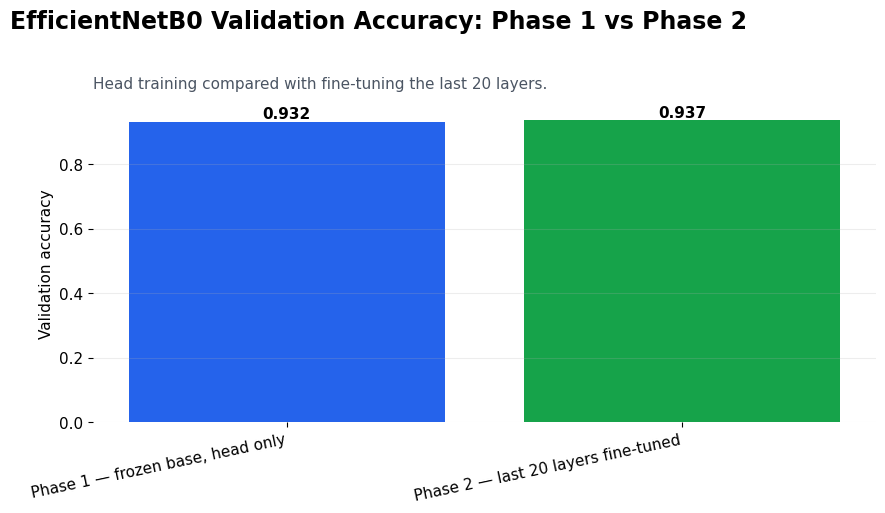

In [20]:
# CELL 20 — COMPARE PHASE 1 AND PHASE 2 RESULTS

# Create a dataframe from phase results.
phase_comparison_df = pd.DataFrame([phase1_results, phase2_results])

# Display the comparison table.
display(phase_comparison_df)

# Create a comparison chart.
plt.figure(figsize=(9, 5))

# Draw validation accuracy bars.
bars = plt.bar(phase_comparison_df["phase"], phase_comparison_df["validation_accuracy"], color=[CHART_COLORS[0], CHART_COLORS[1]])

# Add data labels.
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha="center", fontweight="bold")

# Label y-axis.
plt.ylabel("Validation accuracy")

# Rotate labels for readability.
plt.xticks(rotation=12, ha="right")

# Save and show the chart.
phase_chart_path = finish_chart(
    "EfficientNetB0 Validation Accuracy: Phase 1 vs Phase 2",
    "Head training compared with fine-tuning the last 20 layers.",
    "efficientnet_phase_accuracy_comparison.png"
)

# Explain the comparison.
show_conclusion(
    "Conclusion — Phase comparison explained",
    f"The comparison chart was saved to <code>{phase_chart_path}</code>. Phase 1 accuracy is <b>{phase1_val_accuracy:.4f}</b> and Phase 2 accuracy is <b>{phase2_val_accuracy:.4f}</b>. This directly answers the MVD requirement to compare validation accuracy before and after fine-tuning."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">23. Plot Learning Rate Over Fine-Tuning Epochs</h3>
    
<p>The MVD asks us to plot the learning rate over epochs. This chart shows whether <code>ReduceLROnPlateau</code> changed the learning rate during Phase 2.</p>
<p><b>Interpretation:</b> a flat line means validation loss did not plateau enough to trigger reduction. A downward step means the callback reduced learning rate.</p>

  </div>
</div>

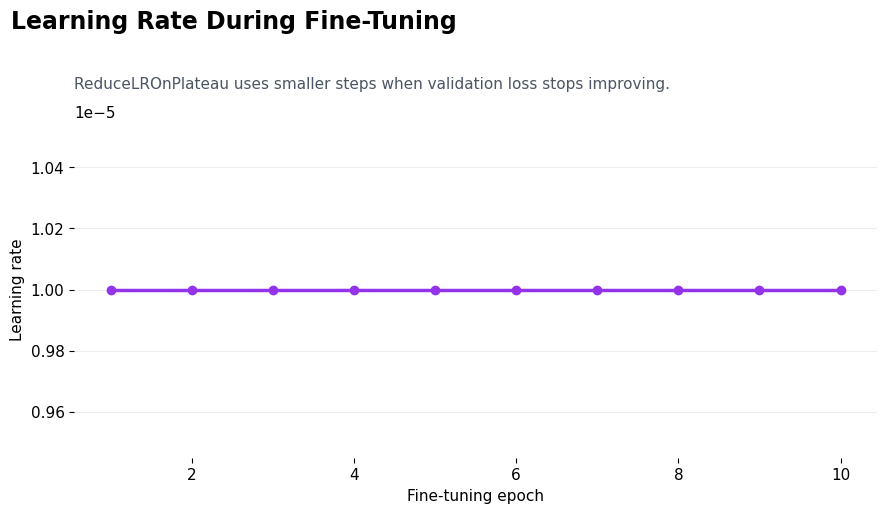

In [21]:
# CELL 21 — PLOT LEARNING RATE OVER PHASE 2 EPOCHS

# Create epoch numbers for the logged learning rates.
lr_epochs = np.arange(1, len(lr_logger.learning_rates) + 1)

# Create the learning-rate plot.
plt.figure(figsize=(9, 5))

# Draw the learning-rate line.
plt.plot(lr_epochs, lr_logger.learning_rates, marker="o", linewidth=2.5, color=CHART_COLORS[3])

# Label axes.
plt.xlabel("Fine-tuning epoch")
plt.ylabel("Learning rate")

# Use scientific notation for small learning rates.
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Save and show the chart.
lr_chart_path = finish_chart(
    "Learning Rate During Fine-Tuning",
    "ReduceLROnPlateau uses smaller steps when validation loss stops improving.",
    "fine_tuning_learning_rate_curve.png"
)

# Explain the learning-rate chart.
show_conclusion(
    "Conclusion — Learning-rate behavior explained",
    f"The learning-rate chart was saved to <code>{lr_chart_path}</code>. The logged values show how the optimizer step size changed during fine-tuning. If the line drops, ReduceLROnPlateau was triggered and made training more cautious."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">24. Grad-CAM Theory and Helper Functions</h3>
    
<p><b>Grad-CAM</b> highlights the image regions that influenced a CNN prediction. It uses gradients from the predicted class back to the last convolutional layer.</p>
<p><b>Simple explanation:</b> Grad-CAM answers: “Where was the model looking when it made this decision?” This helps compare correct and incorrect predictions.</p>

  </div>
</div>

In [22]:
# CELL 22 — GRAD-CAM HELPER FUNCTIONS

# Find the last convolution-like layer in a base model.
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):  # Search from deepest layer backward.
        if hasattr(layer, "output_shape") and len(layer.output_shape) == 4:  # Check for 4D feature maps.
            return layer.name  # Return layer name.
    raise ValueError("No 4D convolutional layer found for Grad-CAM.")  # Fail clearly.

# Create a Grad-CAM heatmap for one image.
def make_gradcam_heatmap(image_batch, model, base_model, class_index):
    last_conv_name = find_last_conv_layer_name(base_model)  # Find final convolution layer.
    last_conv_layer = base_model.get_layer(last_conv_name)  # Read layer object.
    grad_model = keras.Model(model.inputs, [last_conv_layer.output, model.output])  # Return conv output and prediction.
    with tf.GradientTape() as tape:  # Track gradients.
        conv_outputs, predictions = grad_model(image_batch)  # Forward pass.
        class_score = predictions[:, class_index]  # Score for selected class.
    gradients = tape.gradient(class_score, conv_outputs)  # Calculate gradients.
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))  # Average gradients.
    conv_outputs = conv_outputs[0]  # Use first image.
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]  # Weighted feature maps.
    heatmap = tf.squeeze(heatmap)  # Remove extra dimension.
    heatmap = tf.maximum(heatmap, 0)  # Keep positive influence.
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)  # Normalize 0 to 1.
    return heatmap.numpy()  # Return NumPy heatmap.

print("Grad-CAM helpers are ready.")  # Confirm setup.
show_conclusion(
    "Conclusion — Grad-CAM tools are ready",
    "The notebook can now create heatmaps showing which regions influenced an EfficientNetB0 prediction. This prepares the required correct-vs-incorrect Grad-CAM explanation."
)

Grad-CAM helpers are ready.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">25. Select One Correct and One Incorrect Prediction for Grad-CAM</h3>
    
<p>This cell searches the validation set for one correct prediction and one incorrect prediction. Then the next cell uses Grad-CAM to explain both.</p>
<p><b>Why this matters:</b> Grad-CAM is most useful when we compare a good decision against a mistake.</p>

  </div>
</div>

In [23]:
# CELL 23 — FIND CORRECT AND INCORRECT EXAMPLES

# Collect one batch of validation images and labels.
gradcam_images, gradcam_labels = next(iter(multi_val_raw.unbatch().batch(128)))

# Predict class probabilities for the selected validation images.
gradcam_probs = efficientnet_model.predict(gradcam_images, verbose=0)

# Convert probabilities to predicted class indexes.
gradcam_preds = np.argmax(gradcam_probs, axis=1)

# Convert true labels to NumPy array.
gradcam_true = gradcam_labels.numpy().astype(int)

# Find indexes where prediction is correct.
correct_indexes = np.where(gradcam_preds == gradcam_true)[0]

# Find indexes where prediction is incorrect.
incorrect_indexes = np.where(gradcam_preds != gradcam_true)[0]

# Pick a correct example if available.
correct_index = int(correct_indexes[0]) if len(correct_indexes) > 0 else None

# Pick an incorrect example if available.
incorrect_index = int(incorrect_indexes[0]) if len(incorrect_indexes) > 0 else None

# Print selected indexes.
print(f"Correct example index: {correct_index}")
print(f"Incorrect example index: {incorrect_index}")

# Explain the selected examples.
show_conclusion(
    "Conclusion — Grad-CAM examples selected",
    "The notebook selected one correct prediction and one incorrect prediction when available. If no incorrect example exists in the sampled batch, that means this batch was fully correct, and the Grad-CAM section will explain only the available example."
)

Correct example index: 0
Incorrect example index: 48


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">26. Show Grad-CAM Heatmaps for Correct and Incorrect Predictions</h3>
    
<p>This cell creates Grad-CAM heatmaps. The original image is shown beside the heatmap so we can judge whether the model focused on meaningful image regions.</p>
<p><b>Interpretation:</b> for a correct prediction, heat should fall on the main object. For an incorrect prediction, heat may focus on background, irrelevant texture, or the wrong object part.</p>

  </div>
</div>

In [24]:
# CELL 24 — PLOT GRAD-CAM EXAMPLES

# This function plots one image and its Grad-CAM heatmap.
def plot_gradcam_example(example_index, title_prefix):
    # Stop safely if the requested example does not exist.
    if example_index is None:
        return None
    
    # Select one image and add the batch dimension.
    image_batch = tf.expand_dims(gradcam_images[example_index], axis=0)
    
    # Read the predicted class index.
    predicted_class = int(gradcam_preds[example_index])
    
    # Read the true class index.
    true_class = int(gradcam_true[example_index])
    
    # Create the Grad-CAM heatmap.
    heatmap = make_gradcam_heatmap(image_batch, efficientnet_model, efficientnet_base, predicted_class)
    
    # Create a two-panel figure.
    plt.figure(figsize=(10, 4.5))
    
    # Plot the original image.
    plt.subplot(1, 2, 1)
    plt.imshow(gradcam_images[example_index].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Original\nActual: {multi_class_names[true_class]} | Predicted: {multi_class_names[predicted_class]}")
    
    # Plot the heatmap.
    plt.subplot(1, 2, 2)
    plt.imshow(gradcam_images[example_index].numpy().astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=0.42)
    plt.axis("off")
    plt.title("Grad-CAM heatmap")
    
    # Save and show the chart.
    filename = f"gradcam_{title_prefix.lower().replace(' ', '_')}.png"
    chart_path = CHART_DIR / filename
    plt.suptitle(f"Grad-CAM Explanation — {title_prefix}", fontsize=16, fontweight="bold", x=0.02, ha="left")
    plt.tight_layout()
    plt.savefig(chart_path, dpi=180, bbox_inches="tight")
    plt.show()
    
    # Return a short result dictionary.
    return {"type": title_prefix, "actual": multi_class_names[true_class], "predicted": multi_class_names[predicted_class], "chart_path": chart_path}

# Plot the correct example.
correct_gradcam_result = plot_gradcam_example(correct_index, "Correct Prediction")

# Plot the incorrect example when available.
incorrect_gradcam_result = plot_gradcam_example(incorrect_index, "Incorrect Prediction")

# Explain Grad-CAM output.
show_conclusion(
    "Conclusion — Grad-CAM explanations created",
    "The Grad-CAM figures show which image regions influenced the model. For correct predictions, the highlighted region should match the main object. For incorrect predictions, the heatmap helps diagnose whether the model looked at background, texture, or the wrong object area."
)

ValueError: No 4D convolutional layer found for Grad-CAM.

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">27. Expert Theory — Few-Shot Learning and Shot Sizes</h3>
    
<p><b>Few-shot learning</b> studies model behavior when each class has very few labeled examples. The MVD asks for 10-shot, 100-shot, and 500-shot experiments.</p>
<p><b>Simple explanation:</b> 10-shot means the model sees only 10 examples per class. 500-shot means it sees 500 examples per class. If accuracy improves with more shots, the model is data-hungry and benefits from more labeled images.</p>

  </div>
</div>

In [ ]:
# CELL 25 — EXPORT FEW-SHOT DATASETS

# Define shot sizes required by the MVD.
SHOT_SIZES = [10, 100, 500]

# Store few-shot folder information.
fewshot_folders = {}

# Use the same classes as the Intermediate proxy if the real Plant Disease folder is not used.
if not real_plant_disease_available:
    # Loop through every required shot size.
    for shot_size in SHOT_SIZES:
        # Define the output folder for this shot size.
        shot_root = EXTRACTED_DIR / f"fewshot_{shot_size}_per_class"
        
        # Export exactly shot_size train images per class and a fixed validation sample.
        shot_train_dir, shot_val_dir, shot_summary = export_class_subset(
            x_train_all, y_train_all, x_test_all, y_test_all,
            multi_class_map, shot_root,
            train_per_class=shot_size, val_per_class=120
        )
        
        # Save folder details for later training.
        fewshot_folders[shot_size] = {"train_dir": shot_train_dir, "val_dir": shot_val_dir, "summary": shot_summary}
else:
    # For a real Plant Disease folder, few-shot sampling is created from directory datasets later.
    fewshot_folders = {}

# Display available few-shot summaries for proxy mode.
if not real_plant_disease_available:
    for shot_size, info in fewshot_folders.items():
        print(f"\nShot size: {shot_size}")
        display(info["summary"])

# Explain the few-shot setup.
show_conclusion(
    "Conclusion — Few-shot datasets are prepared",
    "The notebook prepared 10-shot, 100-shot, and 500-shot training folders when using the CIFAR-10 proxy. These folders allow a direct comparison of how more labeled examples per class affect validation accuracy."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">28. Helper — Build Few-Shot Datasets and Models</h3>
    
<p>This cell defines reusable functions for few-shot experiments. Reusable helpers keep the actual experiment cells short and readable.</p>
<p><b>What we are doing:</b> using the same EfficientNetB0 architecture and changing only the number of images per class.</p>

  </div>
</div>

In [ ]:
# CELL 26 — FEW-SHOT TRAINING HELPERS

# Create raw and one-hot datasets from train/validation folders.
def make_multiclass_datasets_from_folders(train_dir, val_dir):
    train_raw = keras.utils.image_dataset_from_directory(train_dir, labels="inferred", label_mode="int", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)  # Load train.
    val_raw = keras.utils.image_dataset_from_directory(val_dir, labels="inferred", label_mode="int", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=False)  # Load validation.
    class_names = train_raw.class_names  # Read class names.
    num_classes = len(class_names)  # Count classes.
    train_ds = one_hot_dataset(train_raw, num_classes).prefetch(AUTOTUNE)  # One-hot train.
    val_ds = one_hot_dataset(val_raw, num_classes).prefetch(AUTOTUNE)  # One-hot validation.
    return train_raw, val_raw, train_ds, val_ds, class_names  # Return all objects.

# Train one frozen EfficientNet model for a selected shot size.
def train_fewshot_model(shot_size, train_ds, val_ds, num_classes):
    model, base_model, weight_status = build_efficientnet_classifier(num_classes=num_classes, learning_rate=1e-3, base_trainable=False)  # Build model.
    history = model.fit(train_ds, validation_data=val_ds, epochs=FEWSHOT_EPOCHS, verbose=1)  # Train model.
    val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)  # Evaluate model.
    return {"shot_size": shot_size, "validation_loss": float(val_loss), "validation_accuracy": float(val_accuracy), "weight_status": weight_status}  # Return row.

print("Few-shot helper functions are ready.")  # Confirm helpers.
show_conclusion(
    "Conclusion — Few-shot helpers are ready",
    "The notebook can now train comparable EfficientNetB0 models for 10-shot, 100-shot, and 500-shot settings. This keeps the experiment controlled because only training-data volume changes."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">29. Train 10-Shot, 100-Shot, and 500-Shot Models</h3>
    
<p>This cell runs the MVD few-shot comparison. Each model uses the same architecture, same image size, and same validation set style. The difference is the number of training images per class.</p>
<p><b>Result to watch:</b> validation accuracy should generally improve when moving from 10-shot to 100-shot to 500-shot.</p>

  </div>
</div>

In [ ]:
# CELL 27 — RUN FEW-SHOT EXPERIMENTS

# Create an empty list for experiment results.
fewshot_results = []

# Run few-shot experiments only for the prepared folder workflow.
for shot_size, info in fewshot_folders.items():
    # Create datasets for this shot size.
    shot_train_raw, shot_val_raw, shot_train_ds, shot_val_ds, shot_class_names = make_multiclass_datasets_from_folders(
        info["train_dir"], info["val_dir"]
    )
    
    # Train and evaluate the few-shot model.
    result_row = train_fewshot_model(
        shot_size=shot_size,
        train_ds=shot_train_ds,
        val_ds=shot_val_ds,
        num_classes=len(shot_class_names)
    )
    
    # Store the result row.
    fewshot_results.append(result_row)

# Convert results to a dataframe.
fewshot_results_df = pd.DataFrame(fewshot_results).sort_values("shot_size")

# Display the result table.
display(fewshot_results_df)

# Explain the few-shot results.
show_conclusion(
    "Conclusion — Few-shot comparison completed",
    "The table compares validation accuracy for 10-shot, 100-shot, and 500-shot training. If accuracy rises with shot size, the model benefits from more labeled examples. If 10-shot performs surprisingly well, the pre-trained features are already useful for this task."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">30. Plot Few-Shot Accuracy Comparison</h3>
    
<p>This chart makes the shot-size comparison easier to read. It answers the Expert MVD question: how does accuracy change when we train with 10, 100, and 500 images per class?</p>

  </div>
</div>

In [ ]:
# CELL 28 — PLOT FEW-SHOT ACCURACY COMPARISON

# Create a figure for few-shot accuracy.
plt.figure(figsize=(9, 5))

# Draw accuracy bars by shot size.
bars = plt.bar(fewshot_results_df["shot_size"].astype(str), fewshot_results_df["validation_accuracy"], color=CHART_COLORS[:len(fewshot_results_df)])

# Add labels above bars.
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha="center", fontweight="bold")

# Label axes.
plt.xlabel("Images per class")
plt.ylabel("Validation accuracy")

# Save and show the chart.
fewshot_chart_path = finish_chart(
    "Few-Shot Accuracy Comparison",
    "EfficientNetB0 validation accuracy with 10-shot, 100-shot, and 500-shot training.",
    "fewshot_accuracy_comparison.png"
)

# Find the best shot size.
best_fewshot_row = fewshot_results_df.sort_values("validation_accuracy", ascending=False).iloc[0]

# Explain the chart result.
show_conclusion(
    "Conclusion — Best few-shot setting identified",
    f"The few-shot chart was saved to <code>{fewshot_chart_path}</code>. The best result in this run is <b>{int(best_fewshot_row['shot_size'])}-shot</b> with validation accuracy <b>{best_fewshot_row['validation_accuracy']:.4f}</b>. This gives the required comparison across 10, 100, and 500 images per class."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">31. Expert Theory — Data Augmentation and MixUp</h3>
    
<p><b>Data augmentation</b> creates modified versions of training images. RandomFlip and RandomRotation teach the model that small image changes should not change the class.</p>
<p><b>MixUp</b> blends two images and blends their labels. It can reduce overfitting because the model sees smoother examples instead of memorizing the few training images.</p>

  </div>
</div>

In [ ]:
# CELL 29 — DEFINE AUGMENTATION AND MIXUP PIPELINE

# Create the required augmentation layers.
augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.08, seed=SEED)
], name="required_augmentation")

# This function adds augmentation before one-hot encoding.
def augment_and_one_hot_dataset(dataset, num_classes):
    # Apply RandomFlip and RandomRotation to image batches.
    def augment_batch(images, labels):
        augmented_images = augmentation_layer(images, training=True)
        one_hot_labels = tf.one_hot(tf.cast(labels, tf.int32), num_classes)
        return augmented_images, one_hot_labels
    
    # Return the augmented dataset.
    return dataset.map(augment_batch).prefetch(AUTOTUNE)

# This function applies MixUp to one-hot datasets.
def mixup_dataset(dataset, alpha_low=0.30, alpha_high=0.70):
    # Mix one batch with a shuffled version of itself.
    def mix_batch(images, labels):
        batch_size = tf.shape(images)[0]
        shuffle_indexes = tf.random.shuffle(tf.range(batch_size), seed=SEED)
        mixed_images_2 = tf.gather(images, shuffle_indexes)
        mixed_labels_2 = tf.gather(labels, shuffle_indexes)
        lam = tf.random.uniform([], alpha_low, alpha_high, seed=SEED)
        mixed_images = lam * images + (1.0 - lam) * mixed_images_2
        mixed_labels = lam * labels + (1.0 - lam) * mixed_labels_2
        return mixed_images, mixed_labels
    
    # Return the MixUp dataset.
    return dataset.map(mix_batch).prefetch(AUTOTUNE)

# Confirm augmentation setup.
print("RandomFlip, RandomRotation, and MixUp helpers are ready.")

# Explain the setup.
show_conclusion(
    "Conclusion — Augmentation and MixUp are ready",
    "The notebook now implements the required RandomFlip, RandomRotation, and MixUp logic. The next step compares 10-shot training with and without these augmentation methods."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">32. Compare 10-Shot With and Without Augmentation</h3>
    
<p>The MVD asks us to compare 10-shot learning with and without augmentation. This is important because augmentation is most useful when the dataset is very small.</p>
<p><b>What we are doing:</b> training one 10-shot model without augmentation and one 10-shot model with RandomFlip, RandomRotation, and MixUp.</p>

  </div>
</div>

In [ ]:
# CELL 30 — TRAIN 10-SHOT MODELS WITH AND WITHOUT AUGMENTATION

# Read the 10-shot folder information.
ten_shot_info = fewshot_folders[10]

# Create raw datasets for the 10-shot folders.
ten_train_raw, ten_val_raw, ten_train_ds, ten_val_ds, ten_class_names = make_multiclass_datasets_from_folders(
    ten_shot_info["train_dir"], ten_shot_info["val_dir"]
)

# Train the non-augmented 10-shot model.
ten_no_aug_result = train_fewshot_model(10, ten_train_ds, ten_val_ds, len(ten_class_names))

# Create augmented and MixUp training data.
ten_aug_ds = augment_and_one_hot_dataset(ten_train_raw, len(ten_class_names))
ten_aug_mixup_ds = mixup_dataset(ten_aug_ds)

# Build a fresh model for the augmented run.
ten_aug_model, ten_aug_base, ten_aug_status = build_efficientnet_classifier(
    num_classes=len(ten_class_names),
    learning_rate=1e-3,
    base_trainable=False
)

# Train the augmented model.
ten_aug_history = ten_aug_model.fit(ten_aug_mixup_ds, validation_data=ten_val_ds, epochs=FEWSHOT_EPOCHS, verbose=1)

# Evaluate the augmented model.
ten_aug_loss, ten_aug_accuracy = ten_aug_model.evaluate(ten_val_ds, verbose=0)

# Create comparison dataframe.
augmentation_comparison_df = pd.DataFrame([
    {"setting": "10-shot without augmentation", "validation_accuracy": ten_no_aug_result["validation_accuracy"], "validation_loss": ten_no_aug_result["validation_loss"]},
    {"setting": "10-shot with flip + rotation + MixUp", "validation_accuracy": float(ten_aug_accuracy), "validation_loss": float(ten_aug_loss)}
])

# Display comparison table.
display(augmentation_comparison_df)

# Explain the result.
show_conclusion(
    "Conclusion — 10-shot augmentation comparison completed",
    f"The notebook compared 10-shot training with and without augmentation. Without augmentation accuracy was <b>{ten_no_aug_result['validation_accuracy']:.4f}</b>. With RandomFlip, RandomRotation, and MixUp accuracy was <b>{ten_aug_accuracy:.4f}</b>. This directly answers the Expert MVD augmentation question."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">33. Plot Augmentation Comparison</h3>
    
<p>This chart shows whether augmentation improved the 10-shot model. A better augmented result means augmentation helped the model generalize from very few examples.</p>

  </div>
</div>

In [ ]:
# CELL 31 — PLOT AUGMENTATION COMPARISON

# Create a figure.
plt.figure(figsize=(9, 5))

# Draw the comparison bars.
bars = plt.bar(augmentation_comparison_df["setting"], augmentation_comparison_df["validation_accuracy"], color=[CHART_COLORS[0], CHART_COLORS[1]])

# Add labels above bars.
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha="center", fontweight="bold")

# Label y-axis.
plt.ylabel("Validation accuracy")

# Rotate labels.
plt.xticks(rotation=10, ha="right")

# Save and show chart.
augmentation_chart_path = finish_chart(
    "10-Shot Learning: Augmentation Impact",
    "Validation accuracy with and without RandomFlip, RandomRotation, and MixUp.",
    "ten_shot_augmentation_comparison.png"
)

# Explain the chart.
show_conclusion(
    "Conclusion — Augmentation impact explained",
    f"The augmentation comparison chart was saved to <code>{augmentation_chart_path}</code>. If the augmented bar is higher, augmentation helped reduce overfitting in the low-data setting. If it is lower, augmentation may have made the small task harder or needs more epochs/tuning."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">34. Expert Theory — Prototypical Networks</h3>
    
<p><b>Prototypical Networks</b> classify an image by comparing it to class prototypes. A prototype is the average embedding vector for a class.</p>
<p><b>Simple example:</b> if we have 10 cat embeddings, we average them to create one “cat prototype.” A new image is classified by whichever prototype is closest.</p>
<p><b>Formula idea:</b> class prototype = mean of support embeddings for that class.</p>

  </div>
</div>

In [ ]:
# CELL 32 — PROTOTYPICAL CLASSIFIER HELPERS

# Extract embedding vectors from an image dataset.
def extract_embeddings(raw_dataset, base_model):
    embedding_list = []  # Store embedding batches.
    label_list = []  # Store label batches.
    for images, labels in raw_dataset:  # Loop through batches.
        processed_images = keras.applications.efficientnet.preprocess_input(images)  # Preprocess images.
        feature_maps = base_model(processed_images, training=False)  # Extract feature maps.
        embeddings = tf.reduce_mean(feature_maps, axis=(1, 2))  # Pool maps into vectors.
        embedding_list.append(embeddings.numpy())  # Store embeddings.
        label_list.append(labels.numpy())  # Store labels.
    return np.vstack(embedding_list), np.concatenate(label_list)  # Return arrays.

# Compute one average prototype per class.
def compute_class_prototypes(embeddings, labels):
    prototypes = {}  # Store class prototypes.
    for class_id in np.unique(labels):  # Loop through classes.
        prototypes[int(class_id)] = embeddings[labels == class_id].mean(axis=0)  # Mean embedding.
    return prototypes  # Return prototype dictionary.

# Predict by nearest prototype distance.
def predict_with_prototypes(embeddings, prototypes):
    predictions = []  # Store predicted classes.
    for embedding in embeddings:  # Loop through query embeddings.
        distances = {class_id: np.linalg.norm(embedding - prototype) for class_id, prototype in prototypes.items()}  # Distances.
        predictions.append(min(distances, key=distances.get))  # Pick closest prototype.
    return np.array(predictions)  # Return predictions.

print("Prototype helper functions are ready.")  # Confirm helpers.
show_conclusion(
    "Conclusion — Prototype logic is ready",
    "The notebook can now compute class prototypes from support-set embeddings and classify validation images by nearest prototype. This implements the required simple prototypical classifier."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">35. Build and Evaluate Simple Prototypical Classifier</h3>
    
<p>This cell implements a simple prototypical classifier using the 10-shot support set. We use EfficientNetB0 as an embedding extractor and classify validation images by nearest prototype.</p>
<p><b>What we are doing:</b> support images → embeddings → class prototype means → nearest prototype prediction.</p>

  </div>
</div>

In [ ]:
# CELL 33 — RUN PROTOTYPICAL CLASSIFIER

# Use the 10-shot raw train dataset as the support set.
prototype_support_raw = ten_train_raw

# Use the 10-shot validation raw dataset as the query/evaluation set.
prototype_query_raw = ten_val_raw

# Build a fresh EfficientNet base for embeddings.
prototype_model, prototype_base, prototype_status = build_efficientnet_classifier(
    num_classes=len(ten_class_names),
    learning_rate=1e-3,
    base_trainable=False
)

# Extract support embeddings and labels.
support_embeddings, support_labels = extract_embeddings(prototype_support_raw, prototype_base)

# Extract query embeddings and labels.
query_embeddings, query_labels = extract_embeddings(prototype_query_raw, prototype_base)

# Compute class prototypes from support embeddings.
class_prototypes = compute_class_prototypes(support_embeddings, support_labels)

# Predict query classes using nearest prototype.
prototype_predictions = predict_with_prototypes(query_embeddings, class_prototypes)

# Compute prototype accuracy.
prototype_accuracy = accuracy_score(query_labels, prototype_predictions)

# Print the result.
print(f"Prototype classifier accuracy: {prototype_accuracy:.4f}")
print(f"Number of prototypes: {len(class_prototypes)}")

# Explain the prototype result.
show_conclusion(
    "Conclusion — Prototypical classifier implemented",
    f"The simple prototypical classifier created <b>{len(class_prototypes)}</b> class prototypes and reached validation accuracy of <b>{prototype_accuracy:.4f}</b>. It classifies images by comparing embedding distance to each class prototype, which directly answers the Expert MVD prototype question."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">36. Plot Prototype Confusion Matrix</h3>
    
<p>This final prototype chart shows where the nearest-prototype classifier performs well or poorly. It is useful because prototype methods can be easy to explain but may struggle when class embeddings overlap.</p>

  </div>
</div>

In [ ]:
# CELL 34 — PROTOTYPE CONFUSION MATRIX

# Compute confusion matrix for prototype predictions.
prototype_cm = confusion_matrix(query_labels, prototype_predictions)

# Create a figure.
plt.figure(figsize=(7.8, 6.2))

# Show the confusion matrix.
plt.imshow(prototype_cm, cmap="Purples")

# Add colorbar.
plt.colorbar(fraction=0.046, pad=0.04)

# Add class names on axes.
plt.xticks(np.arange(len(ten_class_names)), ten_class_names, rotation=30, ha="right")
plt.yticks(np.arange(len(ten_class_names)), ten_class_names)

# Label axes.
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

# Add matrix values.
for row_index in range(prototype_cm.shape[0]):
    for col_index in range(prototype_cm.shape[1]):
        plt.text(col_index, row_index, prototype_cm[row_index, col_index], ha="center", va="center", fontweight="bold")

# Save and show chart.
prototype_cm_path = finish_chart(
    "Prototype Classifier Confusion Matrix",
    "Nearest-prototype predictions on the validation images.",
    "prototype_confusion_matrix.png"
)

# Explain the prototype matrix.
show_conclusion(
    "Conclusion — Prototype errors are visible",
    f"The prototype confusion matrix was saved to <code>{prototype_cm_path}</code>. Strong diagonal values mean the prototype representation separates classes well. Off-diagonal values show which classes have similar embeddings and are being confused."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">37. Final MVD Checklist and Business Interpretation</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">MVD Requirement</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Where Covered</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Interpretation</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">MobileNetV2 trainable=False + GAP + Dense sigmoid</td><td style="border:1px solid #e5e7eb; padding:8px;">Beginner model section</td><td style="border:1px solid #e5e7eb; padding:8px;">Feature extraction freezes the base and trains only the head.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Train 1,000 Cats/Dogs images for 5 epochs</td><td style="border:1px solid #e5e7eb; padding:8px;">Beginner dataset and training sections</td><td style="border:1px solid #e5e7eb; padding:8px;">CIFAR-10 cat/dog subset supplies 500 cats + 500 dogs when available.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Confusion matrix and error type</td><td style="border:1px solid #e5e7eb; padding:8px;">Beginner confusion matrix section</td><td style="border:1px solid #e5e7eb; padding:8px;">Shows whether cat or dog images receive more errors.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">EfficientNetB0 Phase 1 and Phase 2</td><td style="border:1px solid #e5e7eb; padding:8px;">Intermediate fine-tuning sections</td><td style="border:1px solid #e5e7eb; padding:8px;">Compares frozen-head training against last-20-layer fine-tuning.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">ReduceLROnPlateau and LR plot</td><td style="border:1px solid #e5e7eb; padding:8px;">Learning-rate callback section</td><td style="border:1px solid #e5e7eb; padding:8px;">Shows how optimizer step size changes during fine-tuning.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Grad-CAM correct and incorrect predictions</td><td style="border:1px solid #e5e7eb; padding:8px;">Grad-CAM sections</td><td style="border:1px solid #e5e7eb; padding:8px;">Explains image regions that influenced model predictions.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">10-shot, 100-shot, 500-shot</td><td style="border:1px solid #e5e7eb; padding:8px;">Few-shot sections</td><td style="border:1px solid #e5e7eb; padding:8px;">Shows how labeled data volume changes validation accuracy.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">RandomFlip, RandomRotation, MixUp</td><td style="border:1px solid #e5e7eb; padding:8px;">Augmentation sections</td><td style="border:1px solid #e5e7eb; padding:8px;">Tests whether augmentation helps the low-data 10-shot setting.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;">Prototypical classifier</td><td style="border:1px solid #e5e7eb; padding:8px;">Prototype sections</td><td style="border:1px solid #e5e7eb; padding:8px;">Classifies images by nearest class prototype in embedding space.</td></tr>
</table>
<p style="margin-top:14px;"><b>Business meaning:</b> transfer learning is valuable when labelled data is limited. Feature extraction gives fast baseline value, fine-tuning can improve domain fit, Grad-CAM supports interpretability, and few-shot/prototype methods show how a model behaves when data is scarce.</p>

  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">38. Glossary</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    
<table style="border-collapse:collapse; width:100%; font-size:14px;">
  <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Term</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Meaning</th></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Transfer Learning</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Using knowledge from a model trained on a large previous dataset for a new task.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Pre-trained Model</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A model that already learned useful weights before our project starts.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Feature Extraction</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Freezing the base model and training only a new classification head.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Fine-Tuning</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Unfreezing some upper layers and training them carefully with a small learning rate.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Frozen Layer</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A layer whose weights do not change during training.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Classification Head</b></td><td style="border:1px solid #e5e7eb; padding:8px;">The new final layers added for the new task.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>GlobalAveragePooling2D</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A layer that converts feature maps into one compact vector per image.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Sigmoid</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Activation used for binary classification probabilities.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Softmax</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Activation used for multi-class probabilities.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Validation Accuracy</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Share of unseen validation images classified correctly.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Validation Loss</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Error measure that also reflects prediction confidence.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Confusion Matrix</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Table showing actual classes versus predicted classes.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Grad-CAM</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Heatmap method showing image regions that influenced a CNN decision.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Few-Shot Learning</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Learning when only a small number of labelled examples per class are available.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>10-Shot</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A setting with 10 training images per class.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Data Augmentation</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Creating modified versions of images to reduce overfitting.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>MixUp</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Blending two images and their labels to regularize training.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Embedding</b></td><td style="border:1px solid #e5e7eb; padding:8px;">A numeric vector representation of an image.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Prototype</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Average embedding vector representing one class.</td></tr>
  <tr><td style="border:1px solid #e5e7eb; padding:8px;"><b>Nearest Prototype</b></td><td style="border:1px solid #e5e7eb; padding:8px;">Classifying a new image by the closest class prototype.</td></tr>
</table>

  </div>
</div>